### MNIST
- MNIST は、「0」~「9」の手書き数字の画像データセット。
- Yann LeCunらによって、手書き文字データセットの NIST データベースから抽出＆加工して、機械学習のチュートリアル用に作成されて公開されている。
- 画像データを説明変数 (X)、ラベルを目的変数 (y) として、多クラス分類問題として、学習モデルを作成する。
- MNISTは、sklearn のサンプルデータセットに含まれています。


画像データ (70000, 784)
ラベル (70000,)
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0 
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0 
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0 
  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 

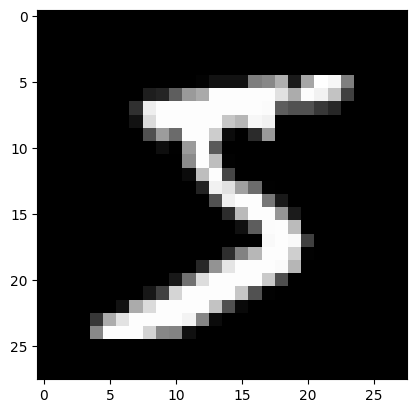

In [1]:
# MNISTデータのダウンロード

from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# MNISTデータセットをダウンロード
# mnist = fetch_openml('mnist_784', as_frame=False, parser='auto', data_home='./temp_mnist') 
# 修正後（ID 554 は MNIST のデータセットIDです）
mnist = fetch_openml(data_id=554, as_frame=False, parser='auto')

print('画像データ', mnist.data.shape)
print('ラベル', mnist.target.shape)

# 画像データは784次元のベクトルで表されているので、28x28の行列に変換して表示する
d = mnist.data[0].reshape([28,28]) # 28x28の行列に変換
for y in range(28): # 28行をループ
    for x in range(28): # 28列をループ
        print(f'{int(d[y,x]):3d}', end=' ') # 画素値を3桁で表示し、スペースで区切る
    print()


plt.imshow(mnist.data[0].reshape(28,28), cmap=plt.cm.gray)
plt.show()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
画像データ (60000, 28, 28)
ラベル (60000,)
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0 
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0 
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0 
  0   0   

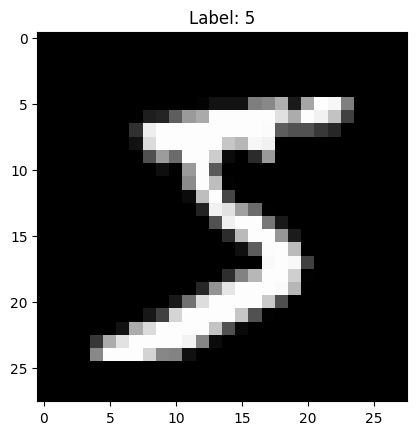

In [2]:
# Kerasを使ってMNISTデータセットをロード
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. MNISTデータセットをロード
# (訓練データ, 訓練ラベル), (テストデータ, テストラベル) のタプルで返ってきます
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print('画像データ', x_train.shape) # (60000, 28, 28)
print('ラベル', y_train.shape)     # (60000,)

# 2. 画像データの中身を数値で表示 (最初のデータ)
# Keras版は最初から 28x28 になっているので reshape は不要です
d = x_train[0]
for y in range(28):
    for x in range(28):
        print(f'{int(d[y,x]):3d}', end=' ')
    print()

# 3. 画像として表示
plt.imshow(x_train[0], cmap=plt.cm.gray)
plt.title(f"Label: {y_train[0]}")
plt.show()

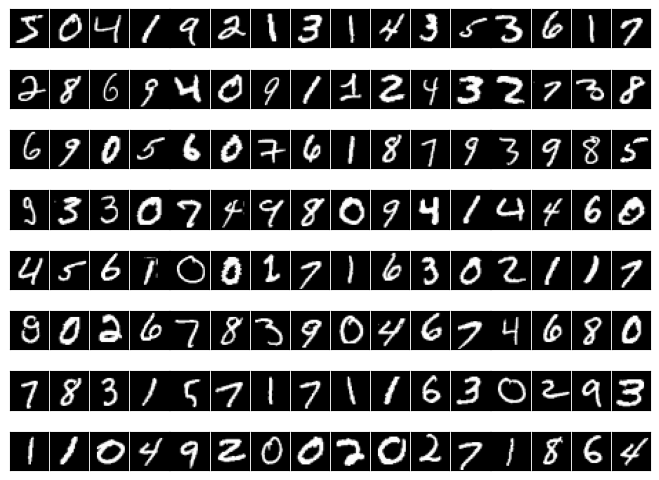

In [3]:
# MNISTデータの画像表示

from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# MNISTデータセットをダウンロード
mnist = fetch_openml('mnist_784', as_frame=False) 

W = 16 # 横に並べる個数
H = 8 # 縦に並べる個数
fig = plt.figure()
fig.subplots_adjust(left=0, right=1, bottom=0, top=1.0, hspace=0.05, wspace=0.05) # サブプロットの余白を調整
for i in range(W*H): # W*H個のサブプロットを作成
    ax = fig.add_subplot(H, W, i + 1, xticks=[], yticks=[]) # サブプロットを追加し、軸の目盛りを消す
    ax.imshow(mnist.data[i].reshape((28, 28)), cmap=plt.cm.gray) # 画像データを28x28の行列に変換して表示
plt.show()

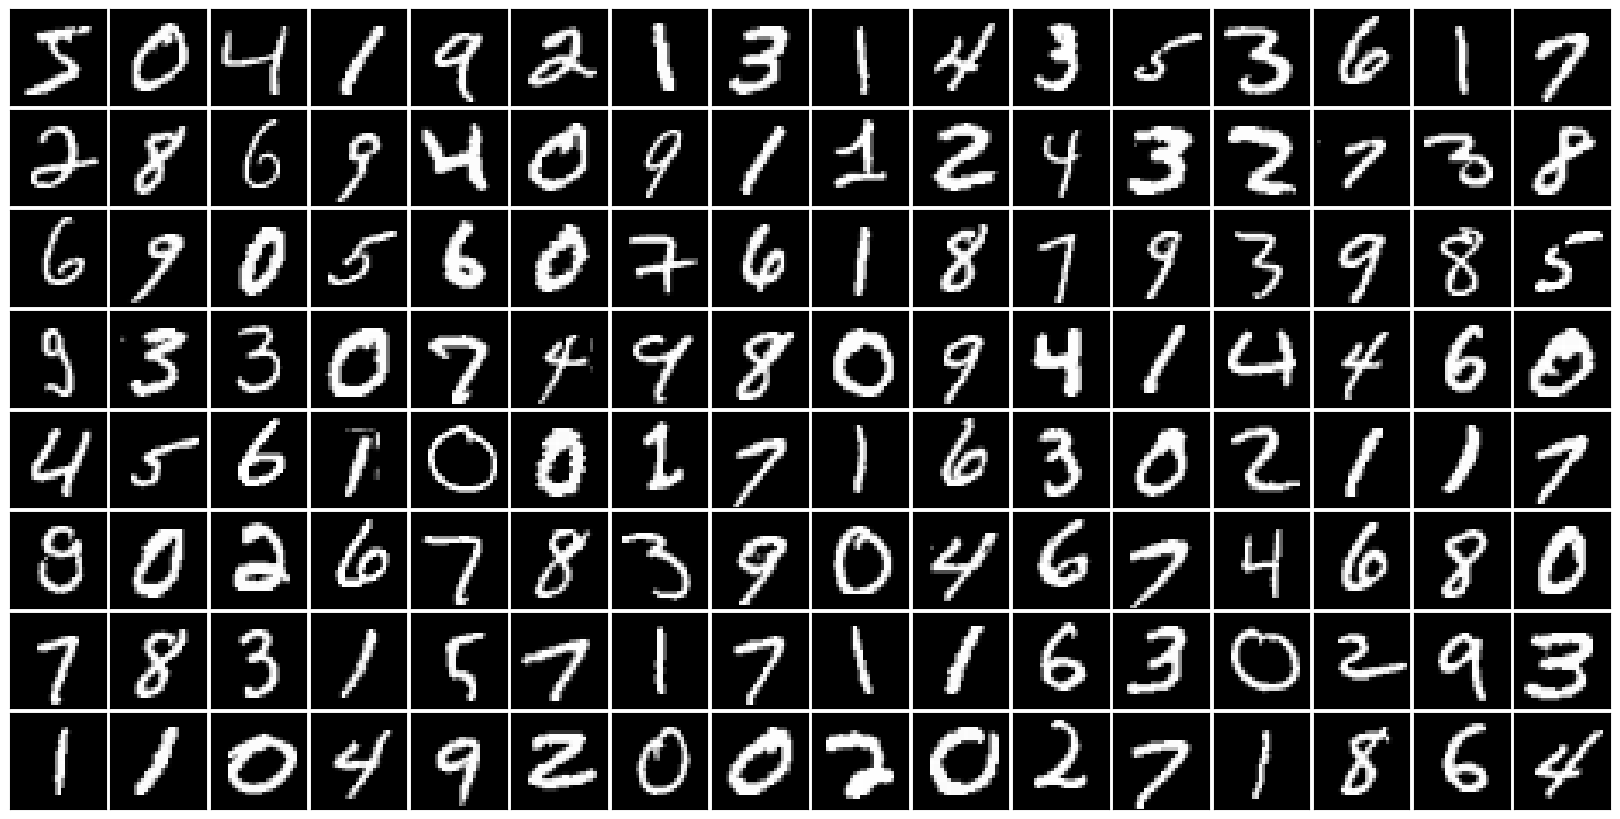

In [ ]:
# Kerasを使ってMNISTデータセットをロードして画像表示
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. MNISTデータセットをロード
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. 表示の設定
W = 16  # 横に並べる個数
H = 8   # 縦に並べる個数

fig = plt.figure(figsize=(W, H)) # 全体のサイズを指定すると見やすくなります
fig.subplots_adjust(left=0, right=1, bottom=0, top=1.0, hspace=0.05, wspace=0.05)

for i in range(W * H):
    ax = fig.add_subplot(H, W, i + 1, xticks=[], yticks=[])
    # Keras版は reshape((28, 28)) が不要！
    ax.imshow(x_train[i], cmap=plt.cm.gray)

plt.show()

### 画像データの分析
画像データ(768次元)を２次元に次元削減して、手書き文字の分布状況をみる。

T-SNEで二次元に削減する。また、2000枚程度に減らしてから処理する。

>**T-SNE（t-distributed Stochastic Neighbor Embedding）**
>- 高次元データを低次元（通常は2次元または3次元）にマッピングするための機械学習アルゴリズム。
>- データの類似性を保ちながら、データポイント間の距離を低次元空間で表現する。
>- つまり、似ているデータは近くに、異なるデータは遠くに配置される。

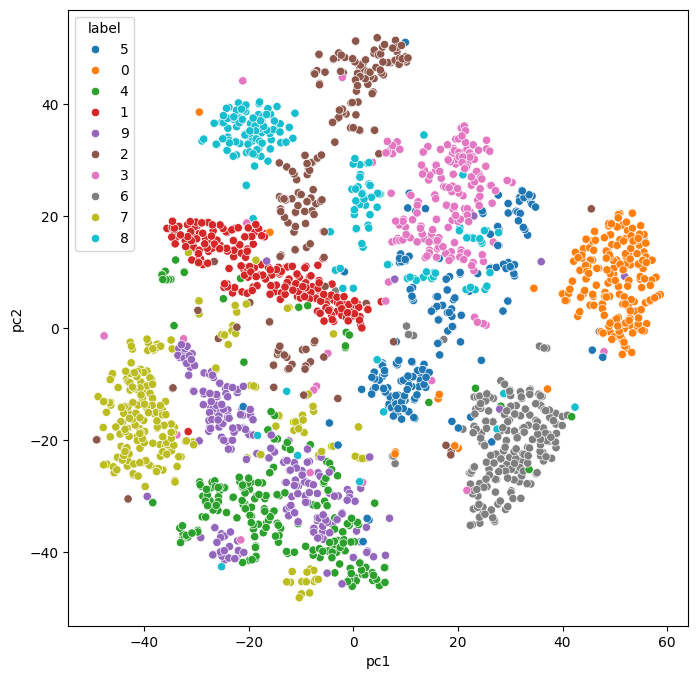

In [4]:
# T-SNEによる次元削減と可視化

from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns

# MNISTデータセットをダウンロード
mnist = fetch_openml('mnist_784', as_frame=False)

tsne = TSNE(n_components=2, random_state=0) # T-SNEのインスタンスを作成
tsne = tsne.fit_transform(mnist.data[:2000]) # 最初の2000個のデータを使って次元削減

df = pd.concat([
    pd.DataFrame(tsne, columns=['pc1', 'pc2']), # T-SNEの結果をデータフレームに変換
    pd.DataFrame(mnist.target[:2000], columns=['label'])], axis=1) # ラベルをデータフレームに変換して結合
plt.figure(figsize=(8, 8)) # 図のサイズを指定
sns.scatterplot(data=df, x='pc1', y='pc2', hue='label') # T-SNEの結果を散布図で表示し、ラベルごとに色分け
plt.show()



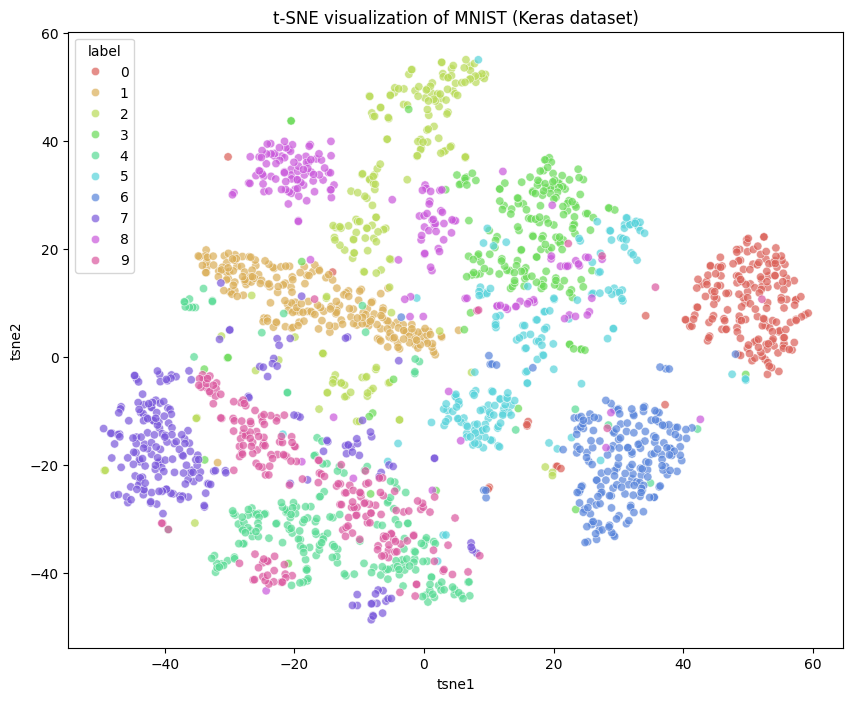

In [ ]:
# Kerasを使ってMNISTデータセットをロードしてT-SNEで次元削減と可視化
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns

# 1. MNISTデータセットをロード
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. データの準備
# t-SNEは2次元配列 (サンプル数, 特徴量数) を受け取るため、28x28を784に平坦化します
num_samples = 2000
x_flat = x_train[:num_samples].reshape(num_samples, 784)
y_subset = y_train[:num_samples]

# 3. t-SNEによる次元削減
tsne = TSNE(n_components=2, random_state=0)
tsne_results = tsne.fit_transform(x_flat)

# 4. データフレームの作成
df = pd.DataFrame(tsne_results, columns=['tsne1', 'tsne2'])
df['label'] = y_subset.astype(str) # 色分け用にラベルを文字列に変換

# 5. 可視化
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df.sort_values('label'), # 凡例の順序を整える
    x='tsne1', y='tsne2', 
    hue='label', 
    palette=sns.color_palette("hls", 10),
    legend="full",
    alpha=0.7
)
plt.title("t-SNE visualization of MNIST (Keras dataset)")
plt.show()

### 訓練データの準備

MNISTの学習モデルを構築するときは、機械学習では、28x28のグレースケールの画像を784次元の多次元データとして扱う。

まず、0〜255のグレースケール画像の値を 0.0〜1.0の範囲に正規化 しておく

In [10]:
# 訓練データの準備

from sklearn.datasets import fetch_openml

# MNISTデータセットをダウンロード
mnist = fetch_openml('mnist_784', as_frame=False)

X = mnist.data.reshape(70000, 784) / 255  # [0,1]で正規化
y = mnist.target.astype(int) # ラベルを整数型に変換

from sklearn.model_selection import train_test_split # 訓練データとテストデータに分割

# stratify=mnist.targetを指定することで、訓練データとテストデータのクラス分布が元のデータセットと同じになるように分割される
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=0, stratify=mnist.target) 

print('訓練データ数:', len(X_train))
print('テストデータ数:', len(X_test))



# MEMO:stratifyについて
# stratifyは、train_test_split関数でデータを分割する際に、指定したラベルの分布を保つための引数。
# 例えば、クラス分類の問題で、あるクラスが全体のデータセットの10%を占めている場合、
# stratifyを指定することで、訓練データとテストデータの両方にそのクラスが10%ずつ含まれるように分割される。
# このことを、層化抽出(比例配分)などとも呼ぶ。
# これにより、モデルの評価がより正確になります。
# 「層化」とも呼ばれる。


訓練データ数: 60000
テストデータ数: 10000


### 多層パーセプトロン
MNISTは、簡単に線形分離できなさそうなので、例としてニューラルネットワークの一種である多層パーセプトロン(MLPClassifier)を使って分類モデルを作る。

`sklearn` モジュールから、`MLPClassifier`をインポートして使う。

#### ハイパーパラメータ
MLPClassifier は、scikit-learnライブラリの中にある多層パーセプトロン (MLP: Multi-layer Perceptron) を用いた分類器。

以下に、主要なハイパーパラメータとその解説を示す。

1. hidden_layer_sizes: `tuple, default=(100,)`
    - 隠れ層のサイズを指定する。例えば、(100,)は1つの隠れ層に100ユニットを持つことを意味する。
    - 複数の隠れ層を持たせたい場合は、(100, 50)のように指定する。
2. activation: `{'identity', 'logistic', 'tanh', 'relu'}, default='relu'`
    - 各隠れ層の活性化関数を指定する。
        - `'identity':` 恒等関数
            -  $ f(x)=x $
        - `'logistic':` シグモイド関数
            - $ f(x)=\frac{1}{1+e^{-x}} $
        - `'tanh':` 双曲線正接関数
            - $ f(x)=tanh(x) $
        - `'relu':` 修正線形単位(ランプ関数)
            - $ f(x)=max(0,x) $
3. solver: `{'lbfgs', 'sgd', 'adam'}, default='adam'`
    - 重みの最適化に用いるアルゴリズムを指定する。
        - `'lbfgs'`: 拡張ベイズ法（準ニュートン法）
        - `'sgd'`: 確率的勾配降下法
        - `'adam'`: アダム（適応的モーメント推定法）
4. learning_rate: `{'constant', 'invscaling', 'adaptive'}, default='constant'`
    - 学習率のスケジュールを指定する。
        - `'constant'`: 固定学習率
        - `'invscaling'`: 初期学習率を徐々に減少させる
        - `'adaptive'`: 以前のエポックでのトレーニング誤差が改善しない場合に学習率を減少させる
5. learning_rate_init: `float, default=0.001`
    - 初期学習率を指定する。
6. max_iter: ` int, default=200`
    - 最大エポック数（反復回数）を指定する。
7. shuffle: `bool, default=True`
    - 各エポックの前にデータをシャッフルするかどうかを指定する。

訓練データ数: 60000
テストデータ数: 10000


c:\Users\44979\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


訓練データに対する正解率: 0.8762333333333333
テストデータに対する正解率: 0.8769


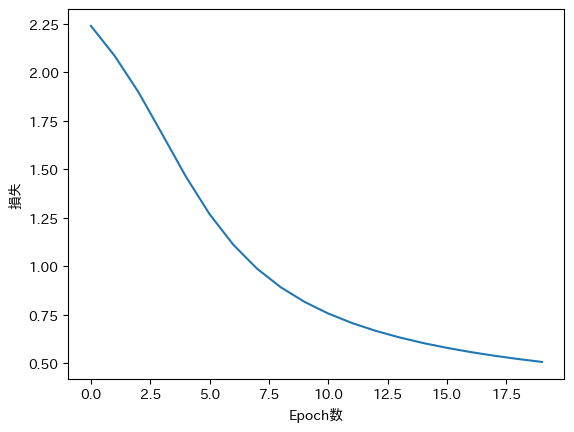

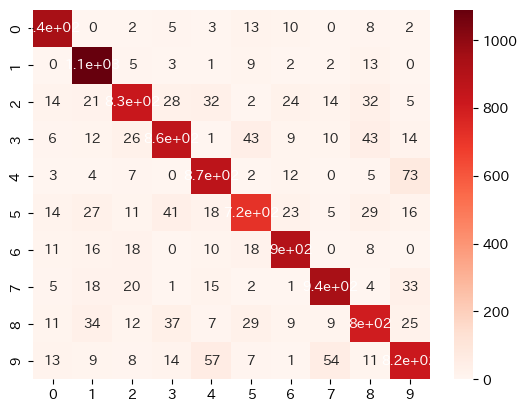

[5 2 6 4 8 2 6 7 3 0]


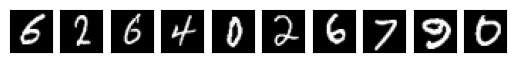

In [ ]:
# ３層パーセプトロンで、活性化関数はシグモイド関数、最適化は確率的勾配降下法を用いて、
# MNISTデータセットの画像認識を行うコード例

from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.metrics import confusion_matrix

# MNISTデータセットをダウンロード
mnist = fetch_openml('mnist_784', as_frame=False)

X = mnist.data.reshape(70000, 784) / 255  # [0,1]で正規化
y = mnist.target.astype(int) # ラベルを整数型に変換

from sklearn.model_selection import train_test_split # 訓練データとテストデータに分割

# stratify=mnist.targetを指定することで、訓練データとテストデータのクラス分布が元のデータセットと同じになるように分割される
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=0, stratify=mnist.target) 

print('訓練データ数:', len(X_train))
print('テストデータ数:', len(X_test))


model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='logistic',
    solver='sgd',
    max_iter=20)


log = model.fit(X_train, y_train)

print('訓練データに対する正解率:', model.score(X_train, y_train))
print('テストデータに対する正解率:', model.score(X_test, y_test))

# 警告は、max_iter=20で学習が収束しなかったことを示している。
# 収束させるためには、max_iterの値を増やすか、solverを変更するなどの対策が必要。


# 学習データをグラフで表示する
plt.plot(log.loss_curve_) # 学習の損失関数の値をエポック数に対してプロット
plt.xlabel('Epoch数')
plt.ylabel('損失')
plt.show()

# ニューラルネットワークでは、損失 (loss) が減少しているときは、まだ順調に学習が進んでいることになりますが、過学習の恐れがあります。


# 混同行列を表示する
y_pred = model.predict(X_test) # テストデータに対する予測ラベルを取得
cm = confusion_matrix(y_test, y_pred) # 混同行列を計算
sns.heatmap(cm, annot=True, cmap='Blues') # 混同行列をヒートマップで表示。annot=Trueでセルに数値を表示、cmap='Blues'で青系のカラーマップを使用
plt.show()



# テストデータの最初の10個の画像と予測されたラベルを表示する関数
def plot_mnist(X, y):
    fig = plt.figure()
    for i in range(10):
        ax = fig.add_subplot(1, 10, i + 1, xticks=[], yticks=[])
        ax.imshow(X[i].reshape((28, 28)), cmap=plt.cm.gray)
    print(y[:10])
    plt.show()

plot_mnist(X_test, y_pred) # テストデータの最初の10個の画像と予測されたラベルを表示


訓練データ数: 60000
テストデータ数: 10000
Epoch 1/20


/Users/moto/.pyenv/versions/3.11.11/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 559us/step - accuracy: 0.7088 - loss: 1.4128 - val_accuracy: 0.8327 - val_loss: 0.8523
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 514us/step - accuracy: 0.8492 - loss: 0.6950 - val_accuracy: 0.8728 - val_loss: 0.5599
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 514us/step - accuracy: 0.8731 - loss: 0.5219 - val_accuracy: 0.8875 - val_loss: 0.4576
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 514us/step - accuracy: 0.8845 - loss: 0.4485 - val_accuracy: 0.8963 - val_loss: 0.4059
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 534us/step - accuracy: 0.8918 - loss: 0.4072 - val_accuracy: 0.8990 - val_loss: 0.3746
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step - accuracy: 0.8964 - loss: 0.3803 - val_accuracy: 0.9030 - val_loss: 0.3530
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 519us/step - accuracy: 0.8995 - loss: 0.3613 - val_accuracy: 0.9080 - val_loss: 0.3374
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 518us/step - accuracy: 0.9027 - loss: 0.34

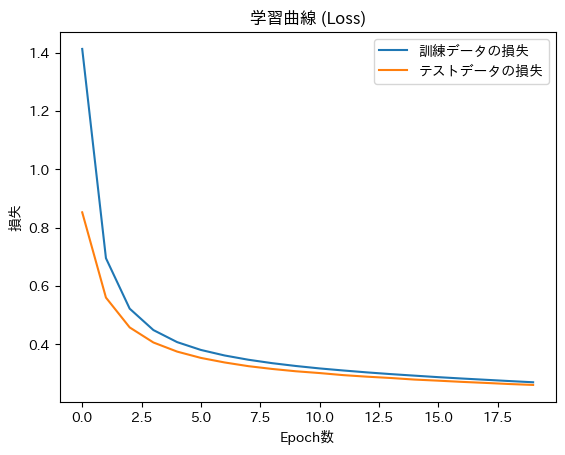

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step


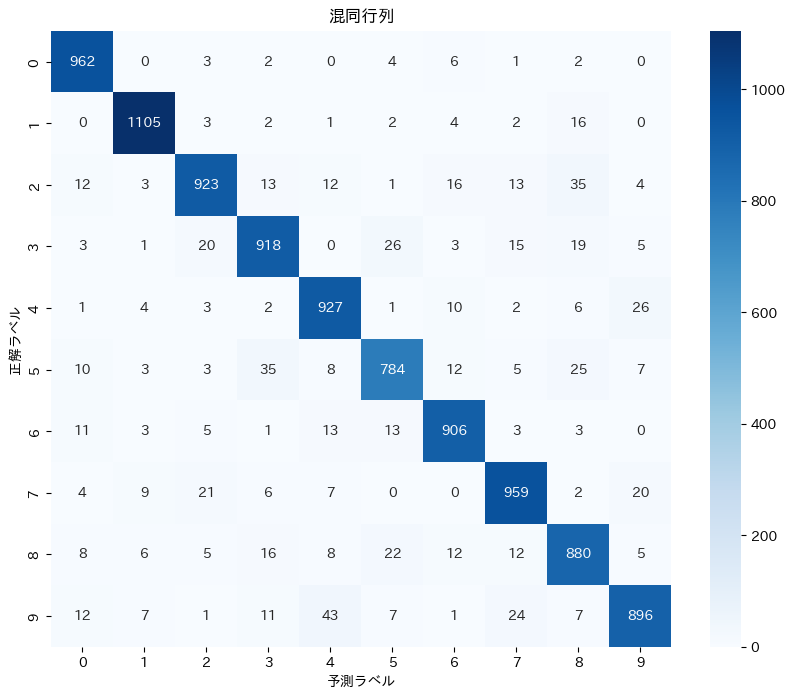

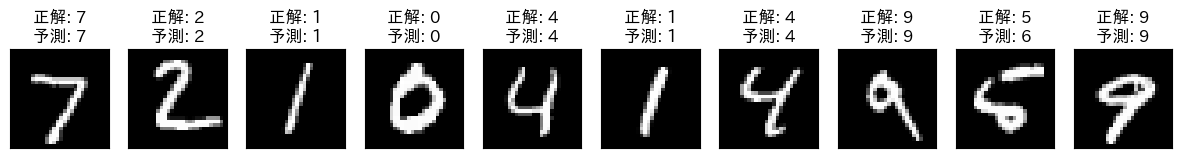

In [ ]:
# Kerasを使ってMNISTデータセットをロードして、3層パーセプトロンで画像認識を行うコード例
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
import japanize_matplotlib

# 1. データセットの読み込みと正規化
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# [0, 255] の値を [0, 1] に正規化
x_train, x_test = x_train / 255.0, x_test / 255.0

print('訓練データ数:', len(x_train))
print('テストデータ数:', len(x_test))

# 2. モデルの構築 (3層パーセプトロン)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),      # 入力層: 28x28を784に平坦化
    layers.Dense(128, activation='sigmoid'),   # 中間層: 128ユニット、シグモイド関数
    layers.Dense(10, activation='softmax')     # 出力層: 10クラス、ソフトマックス
])

# 3. コンパイル (最適化: SGD, 損失関数: 交差エントロピー)
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. 学習の実行
# validation_dataを指定することで、学習中のテストデータへの精度も記録できます
history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test))

# 5. 正解率の表示
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'\n訓練データに対する正解率: {train_acc:.4f}')
print(f'テストデータに対する正解率: {test_acc:.4f}')

# 6. 学習曲線のプロット
plt.plot(history.history['loss'], label='訓練データの損失')
plt.plot(history.history['val_loss'], label='テストデータの損失')
plt.xlabel('Epoch数')
plt.ylabel('損失')
plt.legend()
plt.title('学習曲線 (Loss)')
plt.show()

# 7. 混同行列の表示
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1) # 最大確率のインデックスを予測ラベルとする

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('予測ラベル')
plt.ylabel('正解ラベル')
plt.title('混同行列')
plt.show()

# 8. 予測結果の可視化
def plot_mnist_predictions(X, y_true, y_pred):
    fig = plt.figure(figsize=(15, 3))
    for i in range(10):
        ax = fig.add_subplot(1, 10, i + 1, xticks=[], yticks=[])
        ax.imshow(X[i], cmap='gray')
        ax.set_title(f"正解: {y_true[i]}\n予測: {y_pred[i]}")
    plt.show()

plot_mnist_predictions(x_test, y_test, y_pred)

### 学習済みモデルの保存

機械学習モデルをAIアプリに組み込むときは、毎回、訓練する必要がないように学習済みモデルだけ、ファイルに保存する。



>pickle とは
>- Pythonでのオブジェクトをシリアライズする一般的な方法。
>   - シリアライズ（直列化） とは、プログラミング言語においてオブジェクトをバイト列のデータに表現に変換すること。
>   - 逆に、デシリアライズ（非直列化）とは、シリアライズしたバイト列から元のオブジェクトに復元すること。

In [ ]:
# ３層パーセプトロンで、活性化関数はシグモイド関数、最適化は確率的勾配降下法を用いて、
# MNISTデータセットの画像認識を行うコード例

from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.metrics import confusion_matrix
import pickle

# MNISTデータセットをダウンロード
mnist = fetch_openml('mnist_784', as_frame=False)

X = mnist.data.reshape(70000, 784) / 255  # [0,1]で正規化
y = mnist.target.astype(int) # ラベルを整数型に変換

from sklearn.model_selection import train_test_split # 訓練データとテストデータに分割

# stratify=mnist.targetを指定することで、訓練データとテストデータのクラス分布が元のデータセットと同じになるように分割される
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=0, stratify=mnist.target) 

print('訓練データ数:', len(X_train))
print('テストデータ数:', len(X_test))


model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='logistic',
    solver='sgd',
    max_iter=20)


log = model.fit(X_train, y_train)

print('訓練データに対する正解率:', model.score(X_train, y_train))
print('テストデータに対する正解率:', model.score(X_test, y_test))

# 学習済みモデルをpickleで保存する
with open('./model/mnist-model.pickle', mode='wb') as fp:
    pickle.dump(model, fp)





訓練データ数: 60000
テストデータ数: 10000


c:\Users\44979\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


訓練データに対する正解率: 0.87545
テストデータに対する正解率: 0.8766


In [7]:
# Kerasを使ってMNISTデータセットをロードして、3層パーセプトロンで画像認識を行うコード例
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# 1. データの読み込み
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. モデルの構築 (シグモイド + SGD)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='sigmoid'),
    layers.Dense(10, activation='softmax')
])

# 3. コンパイル
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. 学習
model.fit(x_train, y_train, epochs=20, batch_size=32)

# 5. スコア表示
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'訓練データに対する正解率: {train_acc:.4f}')
print(f'テストデータに対する正解率: {test_acc:.4f}')

# 6. 学習済みモデルの保存
# 保存先ディレクトリの作成（なければ作成）
save_dir = './model'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# TensorFlow標準の形式で保存
model.save(f'{save_dir}/mnist_model.keras')
print(f'モデルを {save_dir}/mnist_model.keras に保存しました。')

Epoch 1/20


c:\Users\44979\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7069 - loss: 1.4310
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8511 - loss: 0.6951
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8733 - loss: 0.5188
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8848 - loss: 0.4452
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8917 - loss: 0.4042
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8969 - loss: 0.3775
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9001 - loss: 0.3585
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9033 - loss: 0.3440
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9062 - loss: 0.3324
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9087 - loss: 0.3226
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9107 - loss: 0.3143
Epoch 12/20
1875/1875 ━━━━━━━━━━━━━━━━━━━

### 自分の手書き文字の認識
画像は、Pillow/PIL ライブラリを用いて操作する

サイズ (746, 746)


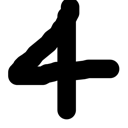

In [ ]:
# 自分で保存した画像を読み込む
from PIL import Image
im = Image.open("./data/4.png")
print('サイズ', im.size)

#im を小さく表示
im.thumbnail((128, 128))
im

In [6]:
# 画像の前処理とモデルへの入力
from PIL import Image
import numpy as np
import pickle


im = Image.open("./data/4.png").convert('L').resize((28,28)) # 画像をグレースケールに変換してから、28x28にリサイズ
im
myimage = np.array(im).reshape(1,-1) # 画像を28x28の行列から、1x784のベクトルに変換
myimage = (255 - myimage)/255 # 画像の色を反転して、[0,1]で正規化
print('前処理後の画像の形状:', myimage.shape) # 画像の前処理が正しく行われているか確認するために、myimageの形状を表示

# 学習済みモデルをpickleで読み込む
with open('./model/mnist-model.pickle', mode='rb') as fp:
    model = pickle.load(fp)

# 画像をモデルに入力して、予測されたラベルを表示する
predicted_label = model.predict(myimage)[0] # 画像をモデルに入力して、予測されたラベルを取得
print('予測されたラベル:', predicted_label)

前処理後の画像の形状: (1, 784)
予測されたラベル: 4


In [9]:
# Kerasを使った学習済みモデルで自分で保存した画像を認識するコード例
import tensorflow as tf
from PIL import Image
import numpy as np

# 1. 画像の読み込みと前処理
# L: グレースケール, 28x28にリサイズ
im = Image.open("./data/4.png").convert('L').resize((28, 28))

# 2. 配列変換と正規化
# Kerasの訓練データに合わせるため (1, 28, 28) の形状にします
myimage = np.array(im)

# MNISTは「黒背景に白文字」なので、もし自作画像が「白背景に黒文字」なら反転が必要
# また、255.0 で割って [0.0, 1.0] に正規化します
myimage = (255 - myimage) / 255.0

# モデルに入力するためにバッチ次元を追加して (1, 28, 28) にする
myimage = myimage[np.newaxis, :, :]

print('前処理後の画像の形状:', myimage.shape) 


# 3. 学習済みモデルをロード (pickleではなくKeras標準メソッド)
model = tf.keras.models.load_model('./model/mnist_model.keras')

# 4. 予測の実行
# predictの結果は各クラスの確率なので、最も高いインデックスを取得
predictions = model.predict(myimage, verbose=0)
predicted_label = np.argmax(predictions, axis=1)[0]

print('予測されたラベル:', predicted_label)

前処理後の画像の形状: (1, 28, 28)
予測されたラベル: 8
